# Laboratory 5 – Exercises


## Exercise 1: PCA and t-SNE Dimensionality Reduction

Use the **iris** dataset in order to reduce its dimensionality down to three dimensions by using the PCA algorithm. Print the principal components and the explained variance ratio and plot the 3D dataset. Also visualize the data reduced to three dimensions using the t-SNE method.


In [77]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.svm import SVC
from sklearn.datasets import load_digits
import sklearn.svm as svm
import sklearn.metrics as metrics
import sklearn.preprocessing as preprocessing
import sklearn.pipeline as pipeline
import sklearn.model_selection as model_selection
import sklearn.decomposition as decomposition
from time import time

In [78]:
iris_dataset = load_iris()
X, y = iris_dataset.data, iris_dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
pca = PCA(n_components=3)
X3D = pca.fit_transform(X_train)
print("PCA Components: ", pca.components_)
print("PCA Explained Variance Ratio: ", pca.explained_variance_ratio_)

PCA Components:  [[ 0.37649644 -0.06637905  0.85134571  0.35924188]
 [ 0.6240207   0.75538031 -0.18479376 -0.07648543]
 [ 0.60667794 -0.57674603 -0.08522779 -0.54040922]]
PCA Explained Variance Ratio:  [0.92743115 0.05245721 0.01557205]


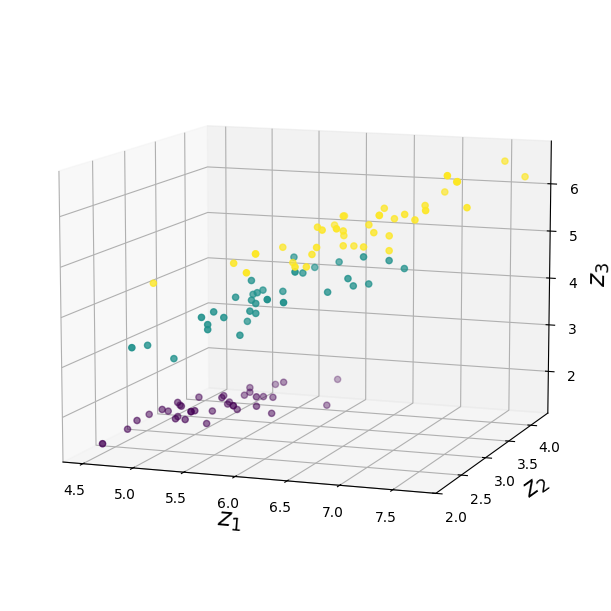

In [79]:
def plot_3d_scatter(X, y, title):
    axes = [
        (X[:, 0]).min(),
        (X[:, 0]).max(),
        (X[:, 1]).min(),
        (X[:, 1]).max(),
        (X[:, 2]).min(),
        (X[:, 2]).max(),
    ]

    fig = plt.figure(figsize=(8, 6), constrained_layout=True)

    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap=plt.cm.viridis)
    ax.view_init(10, -70)
    ax.set_xlabel("$z_1$", fontsize=18)
    ax.set_ylabel("$z_2$", fontsize=18, rotation=0)
    ax.set_zlabel("$z_3$", fontsize=18)

    ax.set_xlim(axes[0:2])
    ax.set_ylim(axes[2:4])
    ax.set_zlim(axes[4:6])

    plt.show()


plot_3d_scatter(X_train, y_train, "PCA")

In [80]:
tsne = TSNE(n_components=3)
X_tsne = tsne.fit_transform(X_train)

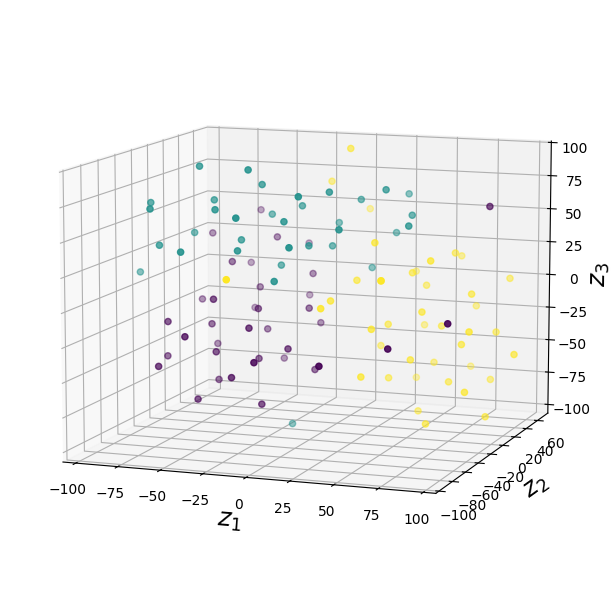

In [81]:
plot_3d_scatter(X_tsne, y_train, "t-SNE")

## Exercise 2: Linear SVM with PCA Comparison

Use the **digits** dataset to perform a classification task using Linear Support Vector Machine (SVM). Set the parameter C to 5. Split the data such that the test split is 25% of the initial dataset. Compare the image classification task using the original number of features (64) to the reduced features (20) using the PCA algorithm. Compare:

- the training time for both models;
- the difference in accuracy score.


In [82]:
digits_dataset = load_digits()
X, y = digits_dataset.data, digits_dataset.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)
svm_model = SVC(kernel="linear", C=5)

In [83]:
t0 = time()
svm_model.fit(X_train, y_train)
t1 = time()
print("Training time: ", t1 - t0)
accuracy_score = svm_model.score(X_test, y_test)
print("Accuracy: ", accuracy_score)

Training time:  0.05685305595397949
Accuracy:  0.9711111111111111


In [84]:
pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
svm_clf = SVC(kernel="linear", C=5)

In [85]:
t0 = time()
svm_clf.fit(X_train_pca, y_train)
t1 = time()
print("Training time: ", t1 - t0)
accuracy_score = svm_model.score(X_test, y_test)
print("Accuracy: ", accuracy_score)

Training time:  0.009289979934692383
Accuracy:  0.9711111111111111
